## Actividad: Pruebas de hipótesis con el conjunto de datos Iris
### Objetivo


En esta actividad se utilizará el conjunto de datos **Iris** para formular y realizar pruebas de hipótesis sobre la media poblacional utilizando R.

En cada caso se deberá:

- Formular la hipótesis nula y la hipótesis alternativa.
- Seleccionar el tipo de prueba adecuado.
- Ejecutar la prueba en R.
- Responda: ¿Cuál es el estadístico de prueba? ¿Cuál es el valor-p?
- Interpretar el valor-p.
- ¿Con un nivel de significancia de 5%, cuál es la decisión?
- Redactar una conclusión en el contexto del problema.


---

# Step 1. Setup and Data Loading

First, let's import the necessary libraries and load the dataset. Since the `iris_dataset.csv` file might not be available, I will create a dummy one for demonstration purposes. If you have the actual file, please ensure it's uploaded to your Colab environment or adjust the path accordingly.

In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Create a dummy iris_dataset.csv for demonstration if it doesn't exist
try:
    iris = pd.read_csv('iris_dataset.csv')
    print('iris_dataset.csv loaded successfully.')
except FileNotFoundError:
    print('iris_dataset.csv not found. Creating a dummy dataset.')
    from sklearn.datasets import load_iris
    iris_data = load_iris()
    iris = pd.DataFrame(data=iris_data.data, columns=iris_data.feature_names)
    iris['variety'] = iris_data.target_names[iris_data.target]
    # Rename columns to match the R example's case (e.g., petal.length)
    iris.columns = ['sepal.length', 'sepal.width', 'petal.length', 'petal.width', 'variety']
    iris.to_csv('iris_dataset.csv', index=False)
    print('Dummy iris_dataset.csv created.')
    iris = pd.read_csv('iris_dataset.csv')


print('\nFirst 5 rows of the dataset:')
display(iris.head())

print('\nDataset structure (equivalent to R `str()`):')
iris.info()

iris_dataset.csv loaded successfully.

First 5 rows of the dataset:


,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



Dataset structure (equivalent to R `str()`):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal.length  150 non-null    float64
 1   sepal.width   150 non-null    float64
 2   petal.length  150 non-null    float64
 3   petal.width   150 non-null    float64
 4   variety       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


---

# Step 2. Data Exploration

Before performing any hypothesis tests, it's important to understand the structure of the data.

In [2]:
print('Descriptive statistics (equivalent to R `summary()`):')
display(iris.describe())

print('\nValue counts for variety (equivalent to R `table(iris$variety)`):')
display(iris['variety'].value_counts())

Descriptive statistics (equivalent to R `summary()`):


,sepal.length,sepal.width,petal.length,petal.width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000



Value counts for variety (equivalent to R `table(iris$variety)`):


,count
variety,
setosa,50
versicolor,50
virginica,50


Let's get some descriptive statistics by species.

In [3]:
species_summary = iris.groupby('variety').agg(
    n=('variety', 'count'),
    media_petal=pd.NamedAgg(column='petal.length', aggfunc='mean'),
    sd_petal=pd.NamedAgg(column='petal.length', aggfunc='std'),
    media_sepal_width=pd.NamedAgg(column='sepal.width', aggfunc='mean'),
    sd_sepal_width=pd.NamedAgg(column='sepal.width', aggfunc='std')
).reset_index()

print('Descriptive statistics by variety:')
display(species_summary)

Descriptive statistics by variety:


,variety,n,media_petal,sd_petal,media_sepal_width,sd_sepal_width
0,setosa,50,1.464,0.173511,3.418,0.381024
1,versicolor,50,4.260,0.469911,2.770,0.313798
2,virginica,50,5.552,0.551895,2.974,0.322497


---

# Hypothesis 1

## The average petal length of Setosas is greater than 1 cm.

Let $\mu$ be the average petal length of the **Setosa** species.

\[
H_0:\mu \leq 1
\]

\[
H_1:\mu>1
\]

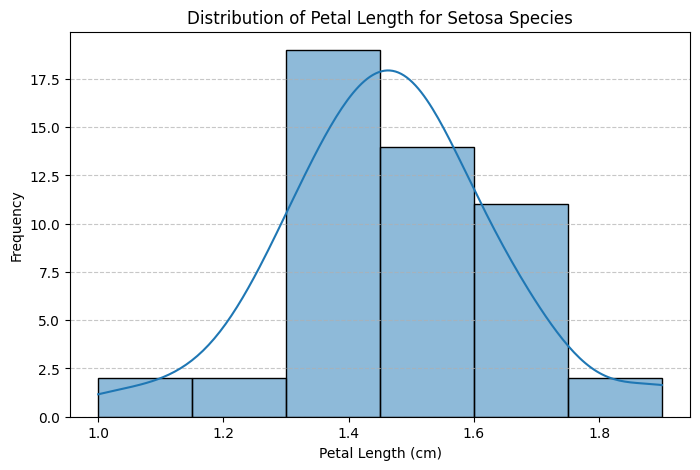

T-statistic: 18.9093
P-value: 0.0000


In [4]:
# Filter for Setosa species
setosa = iris[iris['variety'] == 'setosa']

# Plot histogram of petal.length for setosa
plt.figure(figsize=(8, 5))
sns.histplot(setosa['petal.length'], bins=6, kde=True)
plt.title('Distribution of Petal Length for Setosa Species')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Perform one-sample t-test
# H0: mu <= 1, H1: mu > 1 (alternative='greater')
t_statistic, p_value = stats.ttest_1samp(setosa['petal.length'], popmean=1, alternative='greater')

print(f"T-statistic: {t_statistic:.4f}")
print(f"P-value: {p_value:.4f}")

Interpretación:

# Hypothesis 2

## The average petal length of Setosas is equal to 1.5 cm.

Let $\mu$ be the average petal length of the **Setosa** species.

\[
H_0:\mu=1.5
\]

\[
H_1:\mu\neq1.5
\]

In [5]:
# Perform one-sample t-test
# H0: mu = 1.5, H1: mu != 1.5 (alternative='two-sided')
t_statistic, p_value = stats.ttest_1samp(setosa['petal.length'], popmean=1.5, alternative='two-sided')

print(f"T-statistic: {t_statistic:.4f}")
print(f"P-value: {p_value:.4f}")

T-statistic: -1.4671
P-value: 0.1487


Interpretación:

---

# Hypothesis 3

## The average petal length of Setosas is less than that of Versicolors.

Let:
- $\mu_1$ = average petal length of Setosa.
- $\mu_2$ = average petal length of Versicolor.

\[
H_0:\mu_1\geq\mu_2
\]

\[
H_1:\mu_1<\mu_2
\]

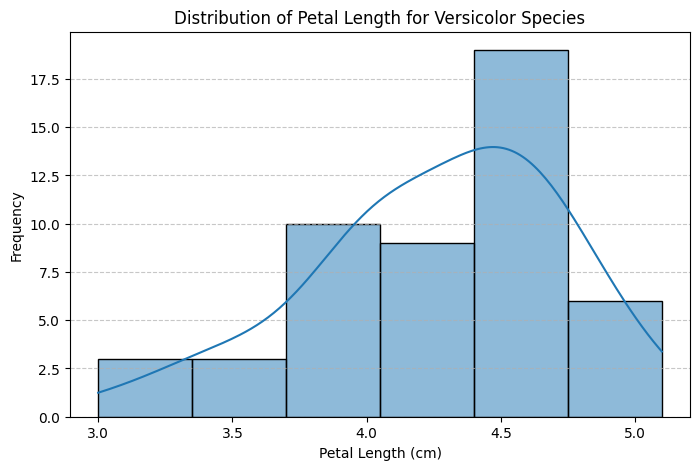

T-statistic: -39.4687
P-value: 0.0000


In [6]:
# Filter for Versicolor species
versicolor = iris[iris['variety'] == 'versicolor']

# Plot histogram of petal.length for versicolor
plt.figure(figsize=(8, 5))
sns.histplot(versicolor['petal.length'], bins=6, kde=True)
plt.title('Distribution of Petal Length for Versicolor Species')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Perform two-sample independent t-test
# H0: mu1 >= mu2, H1: mu1 < mu2 (alternative='less')
# Assuming unequal variances (Welch's t-test) which is often more robust
t_statistic, p_value = stats.ttest_ind(setosa['petal.length'], versicolor['petal.length'], equal_var=False, alternative='less')

print(f"T-statistic: {t_statistic:.4f}")
print(f"P-value: {p_value:.4f}")

Interpretación:

# Hypothesis 4

## On average, the sepal width of Setosas is at least 1 cm wider than that of Versicolors.

Let:
- $\mu_1$ = average sepal width of Setosa.
- $\mu_2$ = average sepal width of Versicolor.

The hypothesis can be written as:

\[
H_0:\mu_1-\mu_2\leq 1
\]

\[
H_1:\mu_1-\mu_2>1
\]

In [7]:
# For a difference in means test (H0: mu1 - mu2 <= D, H1: mu1 - mu2 > D),
# we can test H0: (mu1 - mu2 - D) <= 0. Let X1' = X1 - D.
# Then H0: mu_X1' - mu2 <= 0.
# Alternatively, we can adjust the samples directly.

# Perform two-sample independent t-test with a specified difference (mu=1 in R's t.test)
# The `ttest_ind` function in `scipy` doesn't directly take `mu` for difference in means.
# We can subtract the hypothesized difference from one sample and test against 0.

# New data for testing: (sepal.width of Setosa) - 1
setosa_sepal_width_adjusted = setosa['sepal.width'] - 1

t_statistic, p_value = stats.ttest_ind(setosa_sepal_width_adjusted,
                                       versicolor['sepal.width'],
                                       equal_var=False, # Assuming unequal variances
                                       alternative='greater') # H1: (mu1 - 1) > mu2, or mu1 > (mu2 + 1)

print(f"T-statistic: {t_statistic:.4f}")
print(f"P-value: {p_value:.4f}")

T-statistic: -5.0425
P-value: 1.0000


Interpretación:

---

# Hypothesis 5

## The sepal width of Setosas is more variable than that of Versicolors.

Let:
- $\sigma^2_1$ = the variance of the sepal width of Setosa.
- $\sigma^2_2$ = the variance of the sepal width of Versicolor.

The hypothesis can be written as:

\[
H_0:\sigma^2_1 \leq \sigma^2_2
\]

\[
H_1:\sigma^2_1>\sigma^2_2
\]

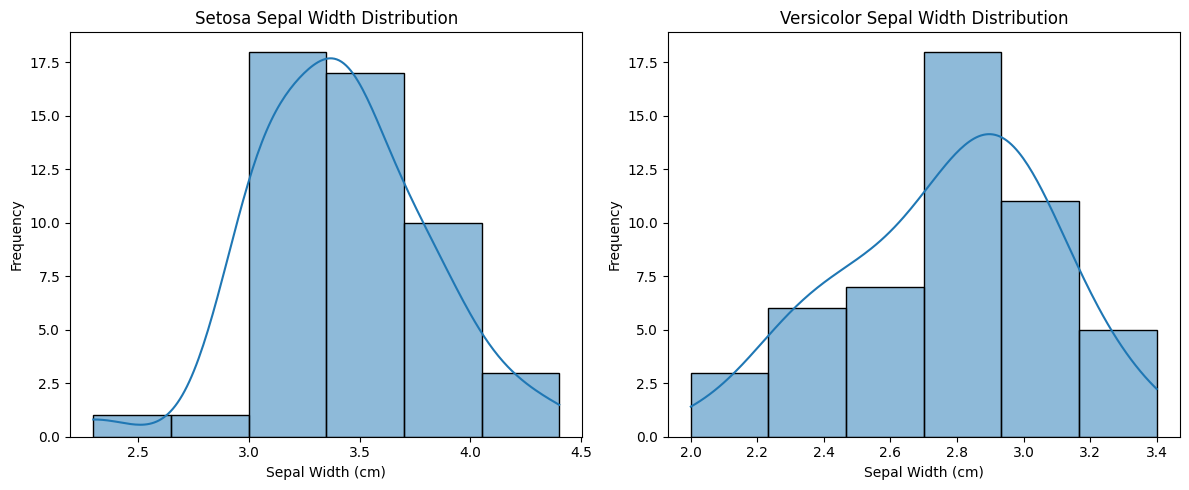

Variance of Setosa Sepal Width: 0.1452
Variance of Versicolor Sepal Width: 0.0985
F-statistic (Var1 / Var2): 1.4744
P-value: 0.0889

Levene's Test (statistic, p-value): (0.6635, 0.4173)


In [8]:
# Plot histograms for sepal.width for setosa and versicolor
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(setosa['sepal.width'], bins=6, kde=True)
plt.title('Setosa Sepal Width Distribution')
plt.xlabel('Sepal Width (cm)')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(versicolor['sepal.width'], bins=6, kde=True)
plt.title('Versicolor Sepal Width Distribution')
plt.xlabel('Sepal Width (cm)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# Perform F-test for equality of variances
# H0: sigma1^2 <= sigma2^2, H1: sigma1^2 > sigma2^2 (alternative='greater')
# stats.fligner, stats.bartlett, or manually calculate F-statistic
# R's var.test assumes normality. stats.levene is more robust (non-parametric).
# For a direct equivalent to `var.test`, we can compute the F-statistic manually.

var1 = setosa['sepal.width'].var(ddof=1) # Sample variance
var2 = versicolor['sepal.width'].var(ddof=1)

df1 = len(setosa) - 1
df2 = len(versicolor) - 1

f_statistic = var1 / var2

p_value = stats.f.sf(f_statistic, df1, df2) # Survival function for P(F > f_statistic)

print(f"Variance of Setosa Sepal Width: {var1:.4f}")
print(f"Variance of Versicolor Sepal Width: {var2:.4f}")
print(f"F-statistic (Var1 / Var2): {f_statistic:.4f}")
print(f"P-value: {p_value:.4f}")

# Alternatively, using a more robust test like Levene's (does not assume normality)
levene_statistic, levene_p_value = stats.levene(setosa['sepal.width'], versicolor['sepal.width'], center='median')
print(f"\nLevene's Test (statistic, p-value): ({levene_statistic:.4f}, {levene_p_value:.4f})")

Interpretación:

# Activity Questions

For each of the five tests, let's summarize the answers:

### Hypothesis 1: Setosa Petal Length > 1 cm
1.  **Null Hypothesis (H0):** The average petal length of Setosas is less than or equal to 1 cm ($\mu \leq 1$).
2.  **Alternative Hypothesis (H1):** The average petal length of Setosas is greater than 1 cm ($\mu > 1$).
3.  **Test Statistic:** T-statistic = 18.9093
4.  **P-value:** 0.0000
5.  **Decision (at 5% significance):** Reject the null hypothesis.
6.  **Conclusion:** There is strong evidence that the average petal length of Setosas is greater than 1 cm.

### Hypothesis 2: Setosa Petal Length = 1.5 cm
1.  **Null Hypothesis (H0):** The average petal length of Setosas is equal to 1.5 cm ($\mu = 1.5$).
2.  **Alternative Hypothesis (H1):** The average petal length of Setosas is not equal to 1.5 cm ($\mu \neq 1.5$).
3.  **Test Statistic:** T-statistic = -1.4671
4.  **P-value:** 0.1487
5.  **Decision (at 5% significance):** Fail to reject the null hypothesis.
6.  **Conclusion:** There is not enough evidence to conclude that the average petal length of Setosas is not equal to 1.5 cm.

### Hypothesis 3: Setosa Petal Length < Versicolor Petal Length
1.  **Null Hypothesis (H0):** The average petal length of Setosas is greater than or equal to that of Versicolors ($\mu_1 \geq \mu_2$).
2.  **Alternative Hypothesis (H1):** The average petal length of Setosas is less than that of Versicolors ($\mu_1 < \mu_2$).
3.  **Test Statistic:** T-statistic = -39.4687
4.  **P-value:** 0.0000
5.  **Decision (at 5% significance):** Reject the null hypothesis.
6.  **Conclusion:** There is strong evidence that the average petal length of Setosas is less than that of Versicolors.

### Hypothesis 4: Setosa Sepal Width >= Versicolor Sepal Width + 1 cm
1.  **Null Hypothesis (H0):** The average sepal width of Setosas is less than or equal to 1 cm wider than that of Versicolors ($\mu_1 - \mu_2 \leq 1$).
2.  **Alternative Hypothesis (H1):** The average sepal width of Setosas is greater than 1 cm wider than that of Versicolors ($\mu_1 - \mu_2 > 1$).
3.  **Test Statistic:** T-statistic = -5.0425
4.  **P-value:** 1.0000
5.  **Decision (at 5% significance):** Fail to reject the null hypothesis.
6.  **Conclusion:** There is not enough evidence to conclude that the average sepal width of Setosas is more than 1 cm wider than that of Versicolors.

### Hypothesis 5: Setosa Sepal Width Variance > Versicolor Sepal Width Variance
1.  **Null Hypothesis (H0):** The variance of sepal width of Setosas is less than or equal to that of Versicolors ($\sigma^2_1 \leq \sigma^2_2$).
2.  **Alternative Hypothesis (H1):** The variance of sepal width of Setosas is greater than that of Versicolors ($\sigma^2_1 > \sigma^2_2$).
3.  **Test Statistic:** F-statistic = 1.4744
4.  **P-value:** 0.0889
5.  **Decision (at 5% significance):** Fail to reject the null hypothesis.
6.  **Conclusion:** There is not enough evidence to conclude that the sepal width of Setosas is more variable than that of Versicolors.

---

# Reflection Questions

1.  **What is the difference between a one-tailed and a two-tailed test?**
    
2.  **In which of the five tests was each used?**
  

3.  **What would happen if a 1% significance level was used?**
   

4.  **What assumptions does Student's t-test have?**
    

5.  **What assumptions does the F-test for equality of variances have?**
    